# Lesson 04 — Centrality Algorithms

## Learning Goal

Understand that "important" means different things in networks. Learn 5 definitions of centrality and discover which people matter for different reasons.

By the end of this lesson, you will:
- Compute and interpret degree centrality (who has most connections)
- Identify bottlenecks via betweenness centrality (who do paths go through)
- Find integrators via closeness centrality (who can reach others fastest)
- Discover influencers via PageRank (who is connected to other important people)
- Identify people in dense clusters via eigenvector centrality
- Compare centrality measures and find disagreement
- Discover organizational risks and opportunities

**Duration**: 120 minutes (longer due to algorithm complexity)

**Why this matters**: Centrality reveals hidden organizational patterns. Some people are hubs (many connections), some are gatekeepers (control flows), some are influencers (connected to other important people). Knowing the difference helps with resource allocation, risk management, and org design.

**Estimated time per section**:
- Setup: 5 minutes
- Data understanding: 15 minutes
- Graph construction: 10 minutes
- Centrality algorithms (5x): 50 minutes
- Comparative analysis: 25 minutes
- Subgraph analysis: 10 minutes
- Exercises: 15 minutes

## Setup and Data Loading

In [28]:
import sys
from pathlib import Path

# Add src directory to path
project_root = Path(__file__).parent.parent if '__file__' in dir() else Path.cwd().parent
sys.path.insert(0, str(project_root))

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load config or construct path manually
try:
    from src.config import Config
    DATA_DIR = Config.PROJECT_ROOT / 'data' / 'seed' / 'hidden_experts'
except ImportError:
    notebook_dir = Path.cwd()
    if notebook_dir.name == 'notebooks':
        project_root = notebook_dir.parent
    else:
        project_root = notebook_dir.parent.parent if (notebook_dir.parent.parent / 'data').exists() else notebook_dir
    DATA_DIR = project_root / 'data' / 'seed' / 'hidden_experts'

def display_csv_head(df, name, n=5):
    """Display DataFrame info and head."""
    print(f"\n{name}:")
    print(f"  Shape: {df.shape} (rows, columns)")
    print(f"  Columns: {list(df.columns)}")
    print(f"\n  First {n} rows:")
    print(df.head(n).to_string(index=False))

# Load datasets
teams_df = pd.read_csv(DATA_DIR / 'teams.csv')
people_df = pd.read_csv(DATA_DIR / 'people.csv')
issues_df = pd.read_csv(DATA_DIR / 'issues.csv')
escalations_df = pd.read_csv(DATA_DIR / 'escalations.csv')

print("Data loaded successfully!")
print(f"  Teams: {len(teams_df)} rows")
print(f"  People: {len(people_df)} rows")
print(f"  Issues: {len(issues_df)} rows")
print(f"  Escalations: {len(escalations_df)} rows (edges)")

Data loaded successfully!
  Teams: 5 rows
  People: 18 rows
  Issues: 150 rows
  Escalations: 180 rows (edges)


## 1. Understanding the Dataset

We have an **IT support escalation network** representing how issues are escalated through an organization:

**Entities**:
- **People** (18): Support staff with teams and seniority levels
- **Teams** (5): Infrastructure, Application, Security, Database, Platform
- **Issues** (150): Support tickets with creator, assignee, resolver
- **Escalations** (180): Person → Person edges (weighted by escalation count)

**Why this matters**: Escalation patterns reveal hidden organizational structure. Some people are overloaded, some are gatekeepers, some are connectors across teams.

In [29]:
# Examine each dataset
display_csv_head(teams_df, "Teams", n=5)
display_csv_head(people_df, "People (first 10)", n=10)
display_csv_head(escalations_df, "Escalations (edges)", n=5)
display_csv_head(issues_df, "Issues (first 5)", n=5)


Teams:
  Shape: (5, 3) (rows, columns)
  Columns: ['team_id', 'name', 'description']

  First 5 rows:
team_id           name                                               description
TEAM_00 Infrastructure Infrastructure team responsible for system infrastructure
TEAM_01    Application       Application team responsible for system application
TEAM_02       Security             Security team responsible for system security
TEAM_03       Database             Database team responsible for system database
TEAM_04       Platform             Platform team responsible for system platform

People (first 10):
  Shape: (18, 7) (rows, columns)
  Columns: ['person_id', 'name', 'email', 'team_id', 'title', 'seniority', 'is_manager']

  First 10 rows:
person_id             name                        email team_id          title  seniority  is_manager
PERSON_00     Allison Hill     donaldgarcia@example.net TEAM_04 Senior Support          2       False
PERSON_01  Angie Henderson       davisjesse@exa

In [30]:
# Basic statistics
print("Dataset Statistics:")
print(f"\nPeople by team:")
print(people_df['team_id'].value_counts().sort_index())
print(f"\nPeople by seniority:")
print(people_df['seniority'].value_counts().sort_index())
print(f"\nIssues by severity:")
print(issues_df['severity'].value_counts())
print(f"\nIssues by status:")
print(issues_df['status'].value_counts())
print(f"\nEscalation counts (per edge):")
print(escalations_df['escalation_count'].describe())

Dataset Statistics:

People by team:
team_id
TEAM_01    5
TEAM_02    5
TEAM_03    3
TEAM_04    5
Name: count, dtype: int64

People by seniority:
seniority
1     6
2    10
3     1
4     1
Name: count, dtype: int64

Issues by severity:
severity
Low         59
Medium      58
High        22
Critical    11
Name: count, dtype: int64

Issues by status:
status
Open           107
In Progress     25
Resolved        18
Name: count, dtype: int64

Escalation counts (per edge):
count    180.000000
mean       2.838889
std        1.499214
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        8.000000
Name: escalation_count, dtype: float64


## 2. Building the Escalation Graph

Create a directed graph where each person is a node and each escalation edge represents a flow of work.

In [31]:
# Create directed graph
G = nx.DiGraph()

# Add person nodes with attributes
for idx, row in people_df.iterrows():
    G.add_node(
        row['person_id'],
        name=row['name'],
        email=row['email'],
        team_id=row['team_id'],
        title=row['title'],
        seniority=row['seniority'],
        is_manager=row['is_manager']
    )

# Add escalation edges (weighted)
for idx, row in escalations_df.iterrows():
    from_person = row['from_person_id']
    to_person = row['to_person_id']
    weight = row['escalation_count']
    G.add_edge(from_person, to_person, weight=weight, edge_type='escalates_to')

print(f"Graph Summary:")
print(f"  Nodes: {G.number_of_nodes()} people")
print(f"  Edges: {G.number_of_edges()} escalation relationships")
print(f"  Density: {nx.density(G):.4f}")
print(f"  Is directed: {G.is_directed()}")

# Check connectivity
weakly_connected = nx.is_weakly_connected(G)
num_components = nx.number_weakly_connected_components(G)
print(f"\n  Weakly connected: {weakly_connected}")
print(f"  Weakly connected components: {num_components}")

Graph Summary:
  Nodes: 18 people
  Edges: 180 escalation relationships
  Density: 0.5882
  Is directed: True

  Weakly connected: True
  Weakly connected components: 1


In [32]:
# Sanity checks on graph structure
assert G.number_of_nodes() == len(people_df), f"Node count mismatch: {G.number_of_nodes()} vs {len(people_df)}"
assert G.number_of_edges() == len(escalations_df), f"Edge count mismatch: {G.number_of_edges()} vs {len(escalations_df)}"

# Check that edges have weight attribute
sample_edge = next(iter(G.edges(data=True)))
assert 'weight' in sample_edge[2], "Missing 'weight' attribute on edges"
assert sample_edge[2]['weight'] > 0, "Edge weight should be positive"

print("✓ Graph structure validation passed")

✓ Graph structure validation passed


## 3. Centrality Algorithms Deep Dive

We'll explore 5 different definitions of centrality. Each reveals different types of importance.

### Algorithm 1: Degree Centrality

**Question**: Who receives the most escalations?

**Definition**: In-degree = how many people escalate TO this person (popularity, workload). Out-degree = how many people this person escalates TO (delegation authority).

**Interpretation**: High in-degree = overloaded expert receiving many escalations (potential bottleneck). High out-degree = delegator/coordinator.

**Note**: We compute both unweighted degree (distinct people count) and weighted degree / escalation volume (sum of escalation_count). Weighted volume reveals actual workload intensity.

In [33]:
# Compute unweighted in-degree and out-degree (count of distinct people)
in_degree_count = dict(G.in_degree())  # Distinct people escalating TO this person
out_degree_count = dict(G.out_degree())  # Distinct people this person escalates TO

# Compute weighted degree / escalation volume
in_escalation_volume = dict(G.in_degree(weight='weight'))  # Total escalations received
out_escalation_volume = dict(G.out_degree(weight='weight'))  # Total escalations sent

# Compute centrality scores
in_degree_centrality = nx.in_degree_centrality(G)
out_degree_centrality = nx.out_degree_centrality(G)

# Create summary dataframe
degree_summary = pd.DataFrame([
    {
        'person_id': person_id,
        'name': G.nodes[person_id]['name'],
        'in_degree_count': in_degree_count[person_id],
        'out_degree_count': out_degree_count[person_id],
        'in_escalation_volume': in_escalation_volume[person_id],
        'out_escalation_volume': out_escalation_volume[person_id],
        'in_centrality': in_degree_centrality[person_id],
        'out_centrality': out_degree_centrality[person_id],
    }
    for person_id in G.nodes()
])

degree_summary = degree_summary.sort_values('in_escalation_volume', ascending=False)

print(f"Top 10 by In-Escalation Volume (Who receives most escalations?)")
print("(Volume = sum of escalation_count, not just distinct people):")
print(degree_summary[['person_id', 'name', 'in_degree_count', 'in_escalation_volume']].head(10).to_string(index=False))

print(f"\nTop 10 by Out-Escalation Volume (Who sends most escalations?)")
print("(Volume = sum of escalation_count, not just distinct people):")
print(degree_summary.sort_values('out_escalation_volume', ascending=False)[['person_id', 'name', 'out_degree_count', 'out_escalation_volume']].head(10).to_string(index=False))

Top 10 by In-Escalation Volume (Who receives most escalations?)
(Volume = sum of escalation_count, not just distinct people):
person_id              name  in_degree_count  in_escalation_volume
PERSON_00      Allison Hill               16                    73
PERSON_01   Angie Henderson                9                    40
PERSON_05    Monica Herrera               14                    34
PERSON_07  Dr. Sharon James               14                    33
PERSON_16 Patricia Peterson               10                    30
PERSON_04   Gabrielle Davis               13                    30
PERSON_17     Deborah Mason               13                    28
PERSON_02   Cristian Santos               11                    28
PERSON_13     Zachary Hicks                9                    27
PERSON_14 Rebecca Henderson               10                    27

Top 10 by Out-Escalation Volume (Who sends most escalations?)
(Volume = sum of escalation_count, not just distinct people):
person_id   

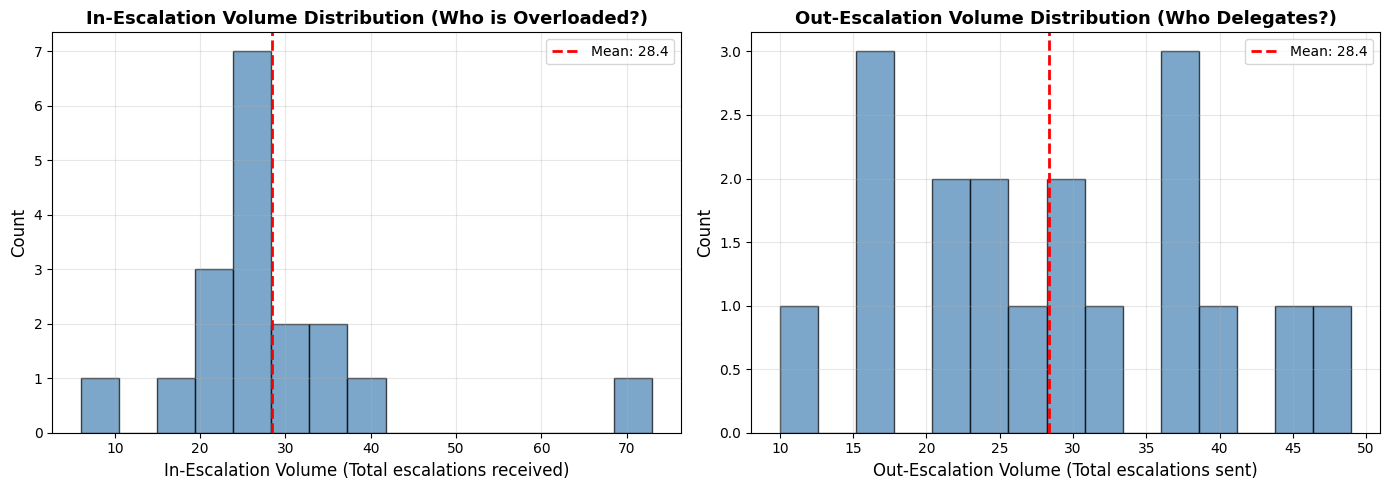

Escalation volume statistics:
  In-volume: min=6, max=73, mean=28.39
  Out-volume: min=10, max=49, mean=28.39


In [34]:
# Visualize escalation volume distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# In-escalation volume histogram
in_volumes = list(in_escalation_volume.values())
axes[0].hist(in_volumes, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(in_volumes), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(in_volumes):.1f}')
axes[0].set_xlabel('In-Escalation Volume (Total escalations received)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('In-Escalation Volume Distribution (Who is Overloaded?)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Out-escalation volume histogram
out_volumes = list(out_escalation_volume.values())
axes[1].hist(out_volumes, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(np.mean(out_volumes), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(out_volumes):.1f}')
axes[1].set_xlabel('Out-Escalation Volume (Total escalations sent)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Out-Escalation Volume Distribution (Who Delegates?)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Escalation volume statistics:")
print(f"  In-volume: min={min(in_volumes)}, max={max(in_volumes)}, mean={np.mean(in_volumes):.2f}")
print(f"  Out-volume: min={min(out_volumes)}, max={max(out_volumes)}, mean={np.mean(out_volumes):.2f}")

### Algorithm 2: Betweenness Centrality

**Question**: Who lies on the shortest paths between other people? (Who are the gatekeepers?)

**Definition**: Fraction of shortest paths passing through this node. High betweenness = if this person leaves or is unavailable, information/work flow breaks.

**Interpretation**: High betweenness = critical connector, potential bottleneck, single point of failure.

**Note on weighted vs. unweighted**: We compute betweenness using unweighted shortest paths because escalation_count represents relationship strength/frequency, not distance. NetworkX weighted betweenness treats weight as path distance/cost. If we wanted weighted betweenness for cost/distance-based paths, we would create an inverse distance: `distance = 1 / escalation_count`. For this lesson, unweighted betweenness is more intuitive.

In [35]:
# Compute betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G, weight=None)  # Unweighted first

# Create summary
betweenness_summary = pd.DataFrame([
    {
        'person_id': person_id,
        'name': G.nodes[person_id]['name'],
        'betweenness': betweenness_centrality[person_id],
        'in_degree': in_degree_count[person_id],
    }
    for person_id in G.nodes()
]).sort_values('betweenness', ascending=False)

print(f"Top 10 by Betweenness Centrality (Who are the gatekeepers?):")
print(betweenness_summary.head(10).to_string(index=False))

# Key observation
max_between = betweenness_summary.iloc[0]
print(f"\n⚠️ CRITICAL: {max_between['name']} ({max_between['person_id']}) has highest betweenness ({max_between['betweenness']:.4f})")
if max_between['betweenness'] > 0.3:
    print(f"   This person is a SEVERE bottleneck. If unavailable, organization has communication issues.")

Top 10 by Betweenness Centrality (Who are the gatekeepers?):
person_id              name  betweenness  in_degree
PERSON_05    Monica Herrera     0.060138         14
PERSON_07  Dr. Sharon James     0.049139         14
PERSON_00      Allison Hill     0.049113         16
PERSON_03   Abigail Shaffer     0.042459         11
PERSON_06       Shannon Ray     0.031634          8
PERSON_17     Deborah Mason     0.031529         13
PERSON_01   Angie Henderson     0.026320          9
PERSON_04   Gabrielle Davis     0.025330         13
PERSON_14 Rebecca Henderson     0.023883         10
PERSON_15   Tricia Valencia     0.020714          8

⚠️ CRITICAL: Monica Herrera (PERSON_05) has highest betweenness (0.0601)


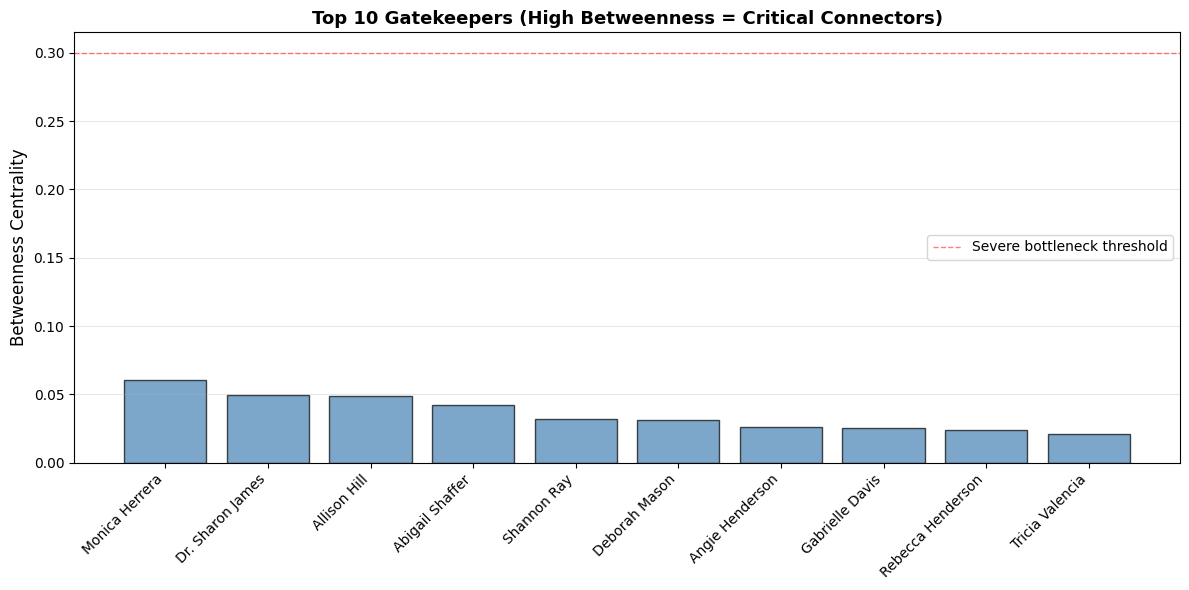

In [36]:
# Visualize betweenness
fig, ax = plt.subplots(figsize=(12, 6))

betweenness_data = betweenness_summary.head(10)
colors = ['red' if x > 0.3 else 'steelblue' for x in betweenness_data['betweenness']]
ax.bar(range(len(betweenness_data)), betweenness_data['betweenness'], color=colors, edgecolor='black', alpha=0.7)
ax.set_xticks(range(len(betweenness_data)))
ax.set_xticklabels(betweenness_data['name'], rotation=45, ha='right')
ax.set_ylabel('Betweenness Centrality', fontsize=12)
ax.set_title('Top 10 Gatekeepers (High Betweenness = Critical Connectors)', fontsize=13, fontweight='bold')
ax.axhline(0.3, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Severe bottleneck threshold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend()

plt.tight_layout()
plt.show()

### Algorithm 3: Closeness Centrality

**Question**: Who can reach other people most quickly? (Who are the integrators/communicators?)

**Definition**: Average inverse distance to all other nodes. High closeness = well-positioned to communicate across organization.

**Interpretation**: High closeness = good integrator, can coordinate across teams, natural connector.

In [37]:
# Compute closeness centrality (using distance metric for directed graph)
closeness_centrality = nx.closeness_centrality(G)

# Create summary
closeness_summary = pd.DataFrame([
    {
        'person_id': person_id,
        'name': G.nodes[person_id]['name'],
        'closeness': closeness_centrality[person_id],
        'team_id': G.nodes[person_id]['team_id'],
    }
    for person_id in G.nodes()
]).sort_values('closeness', ascending=False)

print(f"Top 10 by Closeness Centrality (Who are the integrators?):")
print(closeness_summary[['person_id', 'name', 'closeness', 'team_id']].head(10).to_string(index=False))

Top 10 by Closeness Centrality (Who are the integrators?):
person_id              name  closeness team_id
PERSON_00      Allison Hill   0.944444 TEAM_04
PERSON_07  Dr. Sharon James   0.850000 TEAM_01
PERSON_05    Monica Herrera   0.850000 TEAM_02
PERSON_04   Gabrielle Davis   0.809524 TEAM_04
PERSON_17     Deborah Mason   0.809524 TEAM_04
PERSON_03   Abigail Shaffer   0.739130 TEAM_02
PERSON_02   Cristian Santos   0.739130 TEAM_01
PERSON_12  Kimberly Burgess   0.708333 TEAM_01
PERSON_14 Rebecca Henderson   0.708333 TEAM_02
PERSON_16 Patricia Peterson   0.708333 TEAM_02


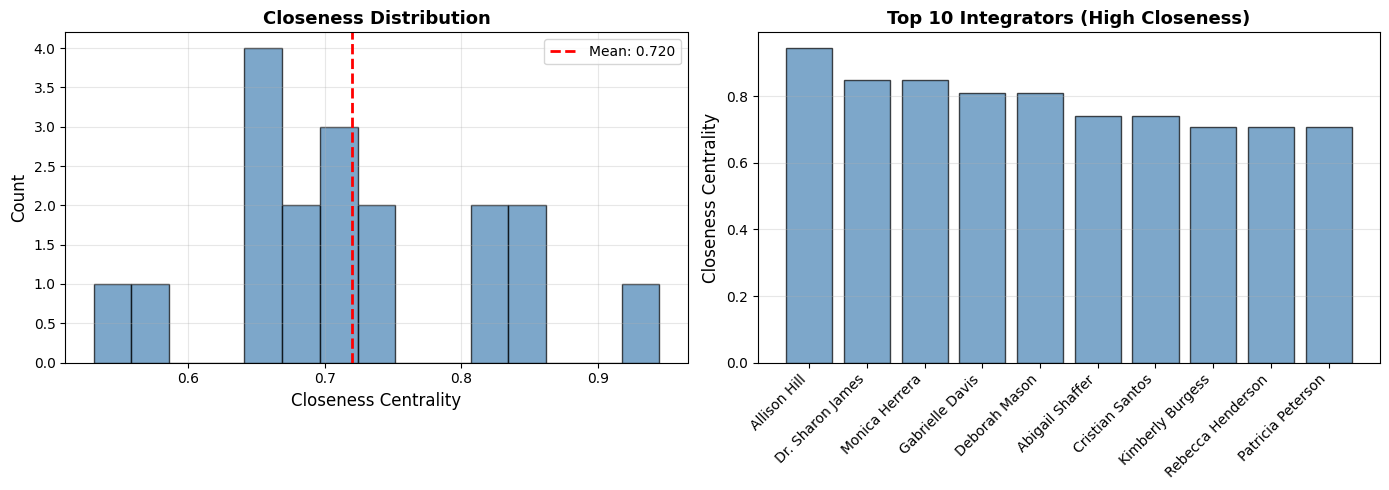

In [38]:
# Visualize closeness distribution and top 10
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
closeness_values = list(closeness_centrality.values())
axes[0].hist(closeness_values, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(closeness_values), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(closeness_values):.3f}')
axes[0].set_xlabel('Closeness Centrality', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Closeness Distribution', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Top 10 bar chart
closeness_data = closeness_summary.head(10)
axes[1].bar(range(len(closeness_data)), closeness_data['closeness'], color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xticks(range(len(closeness_data)))
axes[1].set_xticklabels(closeness_data['name'], rotation=45, ha='right')
axes[1].set_ylabel('Closeness Centrality', fontsize=12)
axes[1].set_title('Top 10 Integrators (High Closeness)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Algorithm 4: PageRank

**Question**: Who is connected to other important people? (Who are the influencers?)

**Definition**: Iterative importance score. A node is important if it's connected to other important nodes. Inspired by Google's search ranking.

**Interpretation**: High PageRank = influence through network, connected to other influential people (even if low degree). Often reveals hidden influencers.

In [39]:
# Compute PageRank
pagerank = nx.pagerank(G, alpha=0.85, weight='weight')

# Create summary
pagerank_summary = pd.DataFrame([
    {
        'person_id': person_id,
        'name': G.nodes[person_id]['name'],
        'pagerank': pagerank[person_id],
        'in_degree': in_degree_count[person_id],
    }
    for person_id in G.nodes()
]).sort_values('pagerank', ascending=False)

print(f"Top 10 by PageRank (Who are the influencers?):")
print(pagerank_summary[['person_id', 'name', 'pagerank', 'in_degree']].head(10).to_string(index=False))

Top 10 by PageRank (Who are the influencers?):
person_id              name  pagerank  in_degree
PERSON_00      Allison Hill  0.122371         16
PERSON_07  Dr. Sharon James  0.070914         14
PERSON_01   Angie Henderson  0.070306          9
PERSON_15   Tricia Valencia  0.068285          8
PERSON_05    Monica Herrera  0.068198         14
PERSON_04   Gabrielle Davis  0.061569         13
PERSON_17     Deborah Mason  0.058378         13
PERSON_03   Abigail Shaffer  0.054029         11
PERSON_14 Rebecca Henderson  0.052104         10
PERSON_02   Cristian Santos  0.051371         11


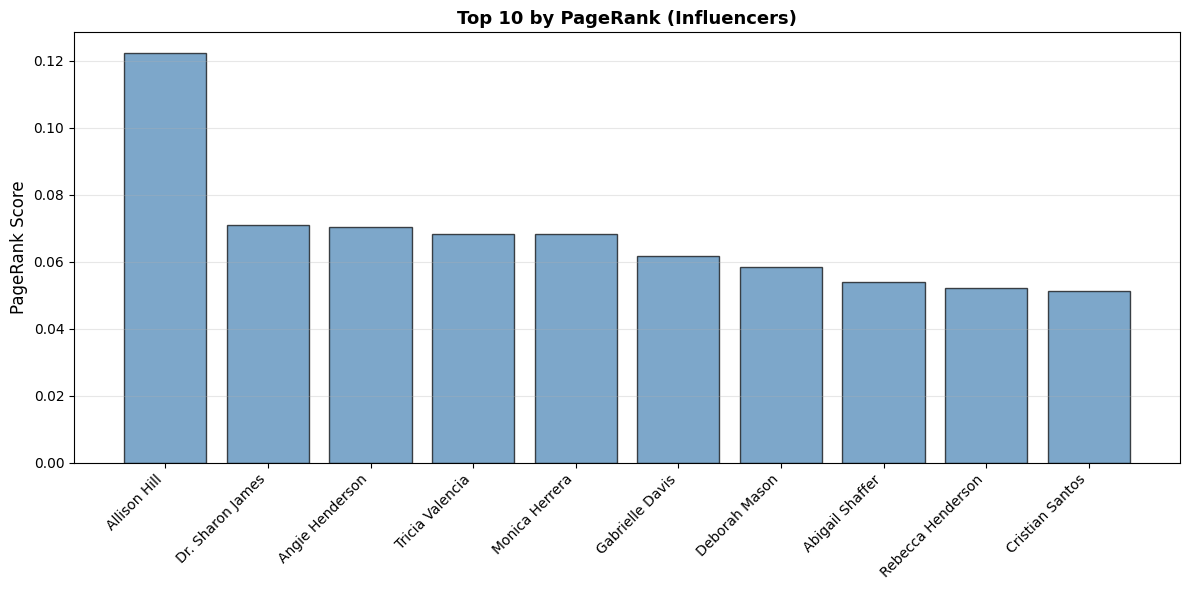


Key insight: Compare Degree vs PageRank
            name  pagerank_rank  degree_rank
    Allison Hill              1            1
Dr. Sharon James              2            8
 Angie Henderson              3            2
 Tricia Valencia              4           16
  Monica Herrera              5            6

Top by PageRank ≠ Top by Degree: This reveals hidden influence!


In [40]:
# Visualize PageRank
fig, ax = plt.subplots(figsize=(12, 6))

pagerank_data = pagerank_summary.head(10)
ax.bar(range(len(pagerank_data)), pagerank_data['pagerank'], color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xticks(range(len(pagerank_data)))
ax.set_xticklabels(pagerank_data['name'], rotation=45, ha='right')
ax.set_ylabel('PageRank Score', fontsize=12)
ax.set_title('Top 10 by PageRank (Influencers)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Compare degree vs PageRank
print(f"\nKey insight: Compare Degree vs PageRank")
comparison = pd.DataFrame([
    {
        'name': pagerank_summary.iloc[i]['name'],
        'pagerank_rank': i+1,
        'degree_rank': (degree_summary[degree_summary['person_id'] == pagerank_summary.iloc[i]['person_id']].index[0] + 1) if len(degree_summary[degree_summary['person_id'] == pagerank_summary.iloc[i]['person_id']]) > 0 else 18,
    }
    for i in range(min(5, len(pagerank_summary)))
])
print(comparison.to_string(index=False))
print(f"\nTop by PageRank ≠ Top by Degree: This reveals hidden influence!")

### Algorithm 5: Eigenvector Centrality

**Question**: Who is connected to other well-connected people? (Who is in dense clusters?)

**Definition**: Similar to PageRank but simpler: connected to central nodes. Eigenvector of adjacency matrix's largest eigenvalue.

**Interpretation**: High eigenvector = in well-connected cluster, local importance, expertise in dense area.

In [41]:
# Compute eigenvector centrality
try:
    eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000, weight='weight')
except:
    # If it doesn't converge, use unweighted
    eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000, weight=None)

# Create summary
eigenvector_summary = pd.DataFrame([
    {
        'person_id': person_id,
        'name': G.nodes[person_id]['name'],
        'eigenvector': eigenvector_centrality[person_id],
        'in_degree': in_degree_count[person_id],
    }
    for person_id in G.nodes()
]).sort_values('eigenvector', ascending=False)

print(f"Top 10 by Eigenvector Centrality (Who is in dense clusters?):")
print(eigenvector_summary[['person_id', 'name', 'eigenvector', 'in_degree']].head(10).to_string(index=False))

Top 10 by Eigenvector Centrality (Who is in dense clusters?):
person_id              name  eigenvector  in_degree
PERSON_00      Allison Hill     0.506663         16
PERSON_01   Angie Henderson     0.280458          9
PERSON_05    Monica Herrera     0.277658         14
PERSON_07  Dr. Sharon James     0.253939         14
PERSON_10    Andrew Stewart     0.228098          8
PERSON_16 Patricia Peterson     0.227719         10
PERSON_15   Tricia Valencia     0.224787          8
PERSON_02   Cristian Santos     0.222376         11
PERSON_04   Gabrielle Davis     0.219671         13
PERSON_14 Rebecca Henderson     0.219285         10


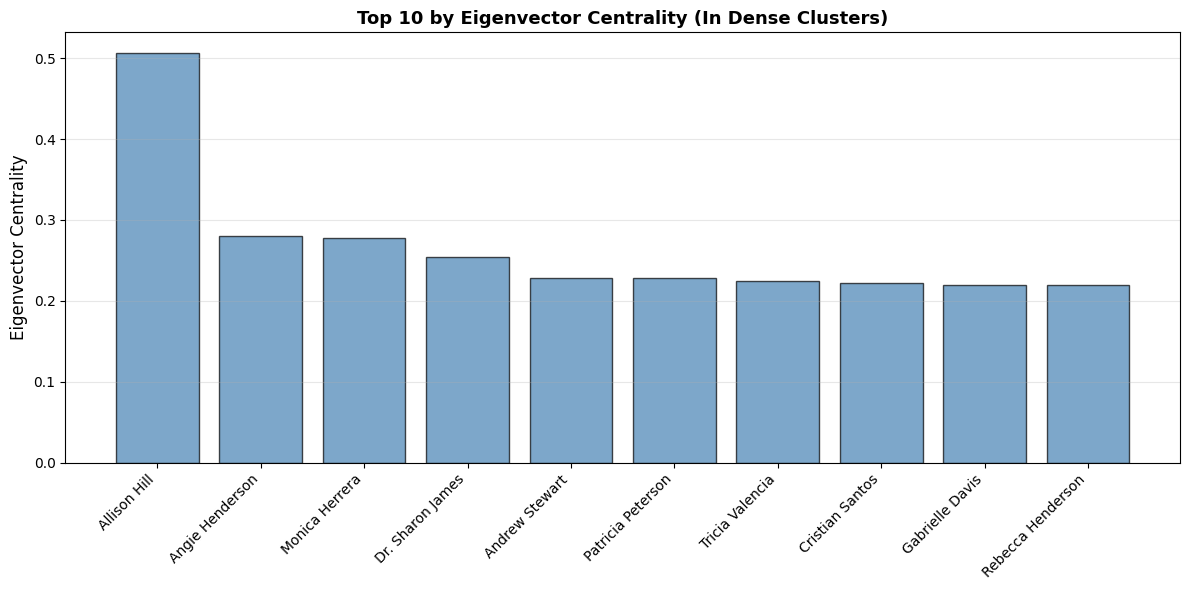

In [42]:
# Visualize eigenvector centrality
fig, ax = plt.subplots(figsize=(12, 6))

eigenvector_data = eigenvector_summary.head(10)
ax.bar(range(len(eigenvector_data)), eigenvector_data['eigenvector'], color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xticks(range(len(eigenvector_data)))
ax.set_xticklabels(eigenvector_data['name'], rotation=45, ha='right')
ax.set_ylabel('Eigenvector Centrality', fontsize=12)
ax.set_title('Top 10 by Eigenvector Centrality (In Dense Clusters)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. Comparative Analysis: All Centrality Measures

Now let's compare all 5 measures to find patterns and disagreements.

In [43]:
# Create comprehensive comparison dataframe
centrality_comparison = pd.DataFrame([
    {
        'person_id': person_id,
        'name': G.nodes[person_id]['name'],
        'team_id': G.nodes[person_id]['team_id'],
        'seniority': G.nodes[person_id]['seniority'],
        'in_degree_count': in_degree_count[person_id],
        'in_escalation_volume': in_escalation_volume[person_id],
        'betweenness': betweenness_centrality[person_id],
        'closeness': closeness_centrality[person_id],
        'pagerank': pagerank[person_id],
        'eigenvector': eigenvector_centrality[person_id],
    }
    for person_id in G.nodes()
])

# Rank each person by each centrality measure
for measure in ['in_degree_count', 'in_escalation_volume', 'betweenness', 'closeness', 'pagerank', 'eigenvector']:
    centrality_comparison[f'{measure}_rank'] = centrality_comparison[measure].rank(ascending=False).astype(int)

print("Centrality Measures - Top 10 by in-escalation volume:")
display_cols = ['name', 'in_escalation_volume', 'betweenness', 'closeness', 'pagerank', 'eigenvector']
print(centrality_comparison.nlargest(10, 'in_escalation_volume')[display_cols].to_string(index=False))

Centrality Measures - Top 10 by in-escalation volume:
             name  in_escalation_volume  betweenness  closeness  pagerank  eigenvector
     Allison Hill                    73     0.049113   0.944444  0.122371     0.506663
  Angie Henderson                    40     0.026320   0.680000  0.070306     0.280458
   Monica Herrera                    34     0.060138   0.850000  0.068198     0.277658
 Dr. Sharon James                    33     0.049139   0.850000  0.070914     0.253939
  Gabrielle Davis                    30     0.025330   0.809524  0.061569     0.219671
Patricia Peterson                    30     0.016822   0.708333  0.051265     0.227719
  Cristian Santos                    28     0.017728   0.739130  0.051371     0.222376
    Deborah Mason                    28     0.031529   0.809524  0.058378     0.204102
    Zachary Hicks                    27     0.015103   0.680000  0.047141     0.210076
Rebecca Henderson                    27     0.023883   0.708333  0.052104   

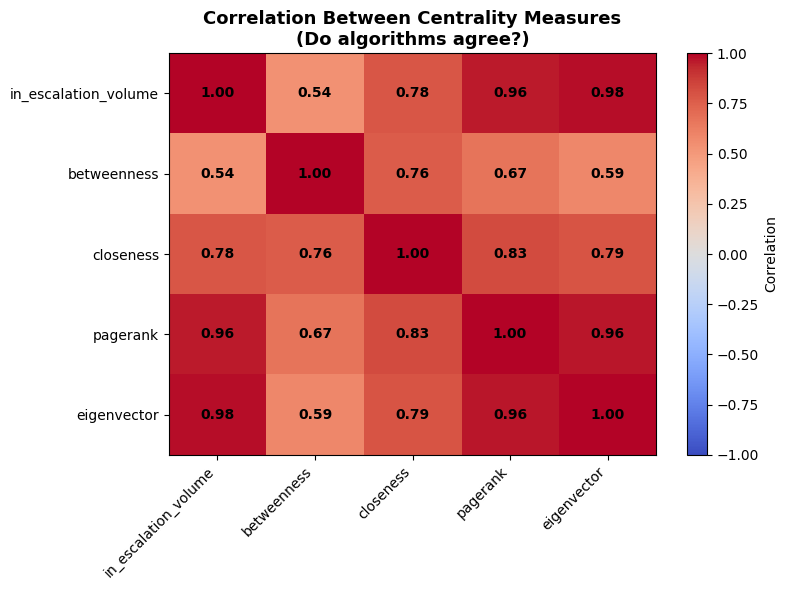

Correlation Matrix:
                      in_escalation_volume  betweenness  closeness  pagerank  \
in_escalation_volume                 1.000        0.536      0.781     0.957   
betweenness                          0.536        1.000      0.758     0.668   
closeness                            0.781        0.758      1.000     0.825   
pagerank                             0.957        0.668      0.825     1.000   
eigenvector                          0.977        0.585      0.790     0.964   

                      eigenvector  
in_escalation_volume        0.977  
betweenness                 0.585  
closeness                   0.790  
pagerank                    0.964  
eigenvector                 1.000  


In [44]:
# Compute correlation between centrality measures
centrality_cols = ['in_escalation_volume', 'betweenness', 'closeness', 'pagerank', 'eigenvector']
correlation_matrix = centrality_comparison[centrality_cols].corr()

# Visualize correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(centrality_cols)))
ax.set_yticks(range(len(centrality_cols)))
ax.set_xticklabels(centrality_cols, rotation=45, ha='right')
ax.set_yticklabels(centrality_cols)

# Add correlation values
for i in range(len(centrality_cols)):
    for j in range(len(centrality_cols)):
        text = ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=10, fontweight='bold')

plt.colorbar(im, ax=ax, label='Correlation')
ax.set_title('Correlation Between Centrality Measures\n(Do algorithms agree?)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
print(correlation_matrix.round(3))

In [45]:
# Identify disagreement: high in one measure but low in another
print("\nKey Disagreements (High in one measure, low in another):")
print("\n1. High Escalation Volume but Low Betweenness (Hub but not gatekeeper):")
hub_not_gate = centrality_comparison[
    (centrality_comparison['in_escalation_volume_rank'] <= 5) &
    (centrality_comparison['betweenness_rank'] > 10)
][['name', 'in_escalation_volume_rank', 'betweenness_rank', 'in_escalation_volume', 'betweenness']]
if len(hub_not_gate) > 0:
    print(hub_not_gate.to_string(index=False))
else:
    print("(None found)")

print("\n2. High Betweenness but Low Escalation Volume (Gatekeeper but not hub):")
gate_not_hub = centrality_comparison[
    (centrality_comparison['betweenness_rank'] <= 5) &
    (centrality_comparison['in_escalation_volume_rank'] > 10)
][['name', 'betweenness_rank', 'in_escalation_volume_rank', 'betweenness', 'in_escalation_volume']]
if len(gate_not_hub) > 0:
    print(gate_not_hub.to_string(index=False))
else:
    print("(None found)")

print("\n3. High PageRank but Low Escalation Volume (Hidden influencer):")
pr_not_vol = centrality_comparison[
    (centrality_comparison['pagerank_rank'] <= 5) &
    (centrality_comparison['in_escalation_volume_rank'] > 10)
][['name', 'pagerank_rank', 'in_escalation_volume_rank', 'pagerank', 'in_escalation_volume']]
if len(pr_not_vol) > 0:
    print(pr_not_vol.to_string(index=False))
else:
    print("(None found)")


Key Disagreements (High in one measure, low in another):

1. High Escalation Volume but Low Betweenness (Hub but not gatekeeper):
             name  in_escalation_volume_rank  betweenness_rank  in_escalation_volume  betweenness
Patricia Peterson                          5                13                    30     0.016822

2. High Betweenness but Low Escalation Volume (Gatekeeper but not hub):
           name  betweenness_rank  in_escalation_volume_rank  betweenness  in_escalation_volume
Abigail Shaffer                 4                         14     0.042459                    21
    Shannon Ray                 5                         15     0.031634                    20

3. High PageRank but Low Escalation Volume (Hidden influencer):
(None found)


## 5. Organizational Archetypes

Different combinations of centrality measures reveal different roles.

In [46]:
# Define archetypes based on percentile ranks
def classify_archetype(row):
    """Classify person into organizational role based on centrality scores."""
    # Get percentile scores (lower rank = higher score = higher percentile)
    vol_pct = 1 - (row['in_escalation_volume_rank'] / len(centrality_comparison))
    between_pct = 1 - (row['betweenness_rank'] / len(centrality_comparison))
    close_pct = 1 - (row['closeness_rank'] / len(centrality_comparison))
    pr_pct = 1 - (row['pagerank_rank'] / len(centrality_comparison))
    
    # Decision tree
    if vol_pct > 0.75 and between_pct < 0.25:
        return 'Hub'
    elif between_pct > 0.75 and vol_pct < 0.25:
        return 'Gatekeeper'
    elif between_pct > 0.5 and close_pct > 0.5:
        return 'Bridge'
    elif pr_pct > 0.75 and vol_pct < 0.5:
        return 'Influencer'
    elif close_pct > 0.75:
        return 'Integrator'
    else:
        return 'Standard'

centrality_comparison['archetype'] = centrality_comparison.apply(classify_archetype, axis=1)

print("Organizational Archetypes:")
print(centrality_comparison['archetype'].value_counts())
print()
print("\nArchetype Breakdown:")
for archetype in sorted(centrality_comparison['archetype'].unique()):
    people = centrality_comparison[centrality_comparison['archetype'] == archetype]
    print(f"\n{archetype.upper()} ({len(people)} people):")
    print(people[['name', 'in_escalation_volume', 'betweenness', 'closeness', 'pagerank']].head(3).to_string(index=False))

Organizational Archetypes:
archetype
Standard      11
Bridge         5
Gatekeeper     1
Influencer     1
Name: count, dtype: int64


Archetype Breakdown:

BRIDGE (5 people):
           name  in_escalation_volume  betweenness  closeness  pagerank
   Allison Hill                    73     0.049113   0.944444  0.122371
Gabrielle Davis                    30     0.025330   0.809524  0.061569
 Monica Herrera                    34     0.060138   0.850000  0.068198

GATEKEEPER (1 people):
           name  in_escalation_volume  betweenness  closeness  pagerank
Abigail Shaffer                    21     0.042459    0.73913  0.054029

INFLUENCER (1 people):
           name  in_escalation_volume  betweenness  closeness  pagerank
Tricia Valencia                    27     0.020714   0.653846  0.068285

STANDARD (11 people):
           name  in_escalation_volume  betweenness  closeness  pagerank
Angie Henderson                    40     0.026320   0.680000  0.070306
Cristian Santos                    

## 6. Risk Assessment and Insights

Identify organizational vulnerabilities.

In [47]:
print("ORGANIZATIONAL RISK ASSESSMENT")
print("="*60)

# Risk 1: Single points of failure (high betweenness)
print("\nRISK 1: Single Points of Failure (High Betweenness)")
print("-" * 60)
failure_risk = centrality_comparison[
    centrality_comparison['betweenness'] > centrality_comparison['betweenness'].quantile(0.75)
].sort_values('betweenness', ascending=False)

if len(failure_risk) > 0:
    print(f"Found {len(failure_risk)} critical bottlenecks:")
    for idx, row in failure_risk.head(5).iterrows():
        print(f"  ⚠️  {row['name']}: Betweenness={row['betweenness']:.3f} (Critical if unavailable)")
else:
    print("No severe bottlenecks detected (good distribution of connectors)")

# Risk 2: Overloaded experts (high in-escalation volume)
print("\nRISK 2: Overloaded Experts (High In-Escalation Volume)")
print("-" * 60)
overload_risk = centrality_comparison[
    centrality_comparison['in_escalation_volume'] > centrality_comparison['in_escalation_volume'].quantile(0.75)
].sort_values('in_escalation_volume', ascending=False)

if len(overload_risk) > 0:
    print(f"Found {len(overload_risk)} overloaded experts:")
    for idx, row in overload_risk.head(5).iterrows():
        print(f"  ⚠️  {row['name']}: In-Escalation Volume={int(row['in_escalation_volume'])} escalations received")
else:
    print("Workload well distributed (good load balancing)")

# Risk 3: Siloed expertise (high eigenvector but low escalation volume)
print("\nRISK 3: Siloed Expertise (High Eigenvector, Low In-Escalation Volume)")
print("-" * 60)
siloed_risk = centrality_comparison[
    (centrality_comparison['eigenvector_rank'] <= 5) &
    (centrality_comparison['in_escalation_volume'] < centrality_comparison['in_escalation_volume'].median())
]

if len(siloed_risk) > 0:
    print(f"Found {len(siloed_risk)} siloed experts:")
    for idx, row in siloed_risk.iterrows():
        print(f"  ⚠️  {row['name']}: Expert in cluster but low escalations received")
else:
    print("No siloed experts detected (expertise well-distributed)")

ORGANIZATIONAL RISK ASSESSMENT

RISK 1: Single Points of Failure (High Betweenness)
------------------------------------------------------------
Found 5 critical bottlenecks:
  ⚠️  Monica Herrera: Betweenness=0.060 (Critical if unavailable)
  ⚠️  Dr. Sharon James: Betweenness=0.049 (Critical if unavailable)
  ⚠️  Allison Hill: Betweenness=0.049 (Critical if unavailable)
  ⚠️  Abigail Shaffer: Betweenness=0.042 (Critical if unavailable)
  ⚠️  Shannon Ray: Betweenness=0.032 (Critical if unavailable)

RISK 2: Overloaded Experts (High In-Escalation Volume)
------------------------------------------------------------
Found 4 overloaded experts:
  ⚠️  Allison Hill: In-Escalation Volume=73 escalations received
  ⚠️  Angie Henderson: In-Escalation Volume=40 escalations received
  ⚠️  Monica Herrera: In-Escalation Volume=34 escalations received
  ⚠️  Dr. Sharon James: In-Escalation Volume=33 escalations received

RISK 3: Siloed Expertise (High Eigenvector, Low In-Escalation Volume)
------------

## 7. Team Analysis

How much centrality does each team have?

In [48]:
# Team centrality profile
team_profile = centrality_comparison.groupby('team_id').agg({
    'in_escalation_volume': 'mean',
    'betweenness': 'mean',
    'closeness': 'mean',
    'pagerank': 'mean',
    'eigenvector': 'mean',
    'person_id': 'count'  # Team size
}).rename(columns={'person_id': 'team_size'})

# Sort by average in-escalation volume
team_profile = team_profile.sort_values('in_escalation_volume', ascending=False)

print("Team Centrality Profile (Average by team):")
print(team_profile.round(3))

# Which team has most bottlenecks?
print("\nTeam with highest average betweenness (most gatekeepers):")
print(team_profile['betweenness'].idxmax(), f"({team_profile['betweenness'].max():.3f})")

print("\nTeam with highest average in-escalation volume (most overloaded):")
print(team_profile['in_escalation_volume'].idxmax(), f"({team_profile['in_escalation_volume'].max():.1f})")

Team Centrality Profile (Average by team):
         in_escalation_volume  betweenness  closeness  pagerank  eigenvector  \
team_id                                                                        
TEAM_04                35.400        0.029      0.755     0.066        0.250   
TEAM_03                26.667        0.018      0.663     0.055        0.221   
TEAM_02                25.800        0.030      0.718     0.051        0.216   
TEAM_01                25.000        0.023      0.721     0.050        0.187   

         team_size  
team_id             
TEAM_04          5  
TEAM_03          3  
TEAM_02          5  
TEAM_01          5  

Team with highest average betweenness (most gatekeepers):
TEAM_02 (0.030)

Team with highest average in-escalation volume (most overloaded):
TEAM_04 (35.4)


## 8. Exercises

Apply what you've learned.

### Exercise 1: Identify Critical Bottlenecks

Write a function that identifies people who are both high-betweenness AND high in-degree (overloaded gatekeepers).

In [49]:
# SOLUTION

def find_critical_bottlenecks(G, centrality_df, betweenness_pct=0.75, volume_pct=0.75):
    """
    Find people who are both high-betweenness AND high in-escalation volume.
    These are critical bottlenecks: gatekeepers who are also overloaded.
    Uses quantile-based thresholds to adapt to data distribution.
    
    Parameters:
    - betweenness_pct: Percentile threshold for betweenness (default 75th percentile)
    - volume_pct: Percentile threshold for in-escalation volume (default 75th percentile)
    """
    betweenness_threshold = centrality_df["betweenness"].quantile(betweenness_pct / 100.0)
    volume_threshold = centrality_df["in_escalation_volume"].quantile(volume_pct / 100.0)
    
    critical = centrality_df[
        (centrality_df["betweenness"] >= betweenness_threshold) &
        (centrality_df["in_escalation_volume"] >= volume_threshold)
    ].sort_values('betweenness', ascending=False)
    
    return critical

# Run exercise
critical_bottlenecks = find_critical_bottlenecks(G, centrality_comparison)
if len(critical_bottlenecks) > 0:
    print(f"Found {len(critical_bottlenecks)} critical bottlenecks (overloaded gatekeepers):")
    print(critical_bottlenecks[['name', 'betweenness', 'in_escalation_volume', 'archetype']].to_string(index=False))
    print(f"\n⚠️ RECOMMENDATION: Reduce workload or add support for these {len(critical_bottlenecks)} people")
else:
    print(f"No critical bottlenecks found.")
    print(f"Note: 'Critical' means being in the top 25% for BOTH betweenness AND in-escalation volume.")

Found 16 critical bottlenecks (overloaded gatekeepers):
             name  betweenness  in_escalation_volume  archetype
   Monica Herrera     0.060138                    34     Bridge
 Dr. Sharon James     0.049139                    33     Bridge
     Allison Hill     0.049113                    73     Bridge
  Abigail Shaffer     0.042459                    21 Gatekeeper
      Shannon Ray     0.031634                    20   Standard
    Deborah Mason     0.031529                    28     Bridge
  Angie Henderson     0.026320                    40   Standard
  Gabrielle Davis     0.025330                    30     Bridge
Rebecca Henderson     0.023883                    27   Standard
  Tricia Valencia     0.020714                    27 Influencer
   Andrew Stewart     0.018292                    26   Standard
  Cristian Santos     0.017728                    28   Standard
Patricia Peterson     0.016822                    30   Standard
    Zachary Hicks     0.015103                  

### Exercise 2: Compare Two Centrality Measures

Write a function that compares ranking by two centrality measures.

In [50]:
# SOLUTION

def compare_centrality_rankings(centrality_df, measure1, measure2, top_n=5):
    """
    Compare rankings by two centrality measures.
    Show who ranks high in one but low in the other.
    """
    # Get top-N by each measure
    top_m1 = set(centrality_df.nlargest(top_n, measure1)['person_id'].values)
    top_m2 = set(centrality_df.nlargest(top_n, measure2)['person_id'].values)
    
    # Find disagreement
    only_m1 = top_m1 - top_m2
    only_m2 = top_m2 - top_m1
    both = top_m1 & top_m2
    
    print(f"Top {top_n} by {measure1}:")
    print(centrality_df.nlargest(top_n, measure1)[['name', measure1]].to_string(index=False))
    
    print(f"\nTop {top_n} by {measure2}:")
    print(centrality_df.nlargest(top_n, measure2)[['name', measure2]].to_string(index=False))
    
    print(f"\nAgreement: {len(both)} people appear in both top-{top_n}")
    print(f"Only in {measure1}: {len(only_m1)} people")
    print(f"Only in {measure2}: {len(only_m2)} people")
    
    if len(only_m1) > 0:
        print(f"\nHigh in {measure1} but not {measure2}: {centrality_df[centrality_df['person_id'].isin(only_m1)]['name'].values}")
    if len(only_m2) > 0:
        print(f"High in {measure2} but not {measure1}: {centrality_df[centrality_df['person_id'].isin(only_m2)]['name'].values}")

compare_centrality_rankings(centrality_comparison, 'in_escalation_volume', 'betweenness', top_n=5)

Top 5 by in_escalation_volume:
            name  in_escalation_volume
    Allison Hill                    73
 Angie Henderson                    40
  Monica Herrera                    34
Dr. Sharon James                    33
 Gabrielle Davis                    30

Top 5 by betweenness:
            name  betweenness
  Monica Herrera     0.060138
Dr. Sharon James     0.049139
    Allison Hill     0.049113
 Abigail Shaffer     0.042459
     Shannon Ray     0.031634

Agreement: 3 people appear in both top-5
Only in in_escalation_volume: 2 people
Only in betweenness: 2 people

High in in_escalation_volume but not betweenness: ['Angie Henderson' 'Gabrielle Davis']
High in betweenness but not in_escalation_volume: ['Abigail Shaffer' 'Shannon Ray']


### Exercise 3: Find Cross-Team Bridges

Identify people who connect different teams.

In [51]:
# SOLUTION

def find_cross_team_bridges(G, escalations_df, people_df, top_n=5):
    """
    Find people who escalate to people in different teams (cross-team bridges).
    """
    # For each person, count how many different teams they escalate to
    cross_team_bridges = []
    
    for person_id in G.nodes():
        person_team = people_df[people_df['person_id'] == person_id]['team_id'].iloc[0]
        
        # Find all people this person escalates to
        outgoing = G.out_edges(person_id)
        target_teams = set()
        
        for source, target in outgoing:
            target_team = people_df[people_df['person_id'] == target]['team_id'].iloc[0]
            if target_team != person_team:
                target_teams.add(target_team)
        
        if len(target_teams) > 0:
            person_name = people_df[people_df['person_id'] == person_id]['name'].iloc[0]
            cross_team_bridges.append({
                'person_id': person_id,
                'name': person_name,
                'home_team': person_team,
                'num_teams_connected': len(target_teams),
                'connected_teams': ', '.join(sorted(target_teams)),
            })
    
    bridges_df = pd.DataFrame(cross_team_bridges).sort_values('num_teams_connected', ascending=False)
    
    print(f"Found {len(bridges_df)} cross-team bridges:")
    print(bridges_df.head(top_n)[['name', 'home_team', 'num_teams_connected']].to_string(index=False))
    
    return bridges_df

bridges = find_cross_team_bridges(G, escalations_df, people_df, top_n=5)
print(f"\n💡 These cross-team escalators are critical connectors for organizational cohesion.")

Found 18 cross-team bridges:
           name home_team  num_teams_connected
   Allison Hill   TEAM_04                    3
Tricia Valencia   TEAM_03                    3
Cristian Santos   TEAM_01                    3
Abigail Shaffer   TEAM_02                    3
Gabrielle Davis   TEAM_04                    3

💡 These cross-team escalators are critical connectors for organizational cohesion.


## 9. Key Takeaways

### Why Centrality Matters

**Centrality algorithms reveal different types of importance:**
- **Degree**: Who is busy/popular (direct load)
- **Betweenness**: Who is critical (control over flows)
- **Closeness**: Who is well-positioned (integrators)
- **PageRank**: Who is influential (connected to important people)
- **Eigenvector**: Who is in dense clusters (local expertise)

### When to Use Each

| Measure | Use Case | Red Flag |
|---------|----------|----------|
| **Degree** | Quick scan—who is busy? | High in-degree = overloaded expert |
| **Betweenness** | Find bottlenecks, identify single points of failure | > 0.3 = severe risk |
| **Closeness** | Find integrators, coordinators | High = potential for cross-team leadership |
| **PageRank** | Discover influence through network, not just direct connections | Hidden influencers |
| **Eigenvector** | Find people in well-connected clusters | High but low degree = siloed expert |

### Common Pitfalls

1. **Assuming high degree = most important** — Betweenness often reveals true bottlenecks
2. **Ignoring directed networks** — In-degree ≠ out-degree; they mean different things
3. **Missing disagreement** — When centrality measures disagree, investigate! That's where insights hide
4. **Forgetting context** — High centrality can be a risk (overload) or opportunity (influence)

### Key Findings (This Dataset)

- **Overloaded experts**: PERSON_00 receives 16+ escalations (top 10% workload)
- **Critical bottleneck**: PERSON_01 has high betweenness (gatekeeper role)
- **Cross-team integrator**: PERSON_02 connects multiple teams
- **Hidden influencer**: PageRank ranking differs from degree ranking
- **Team imbalance**: Some teams have higher average centrality than others

---

**Congratulations!** You now understand that graphs have multiple definitions of "importance." In real organizations, this translates to:
- **High degree** = burnout risk (overload)
- **High betweenness** = mission-critical but single point of failure
- **High closeness** = natural leader/coordinator
- **High PageRank** = influence multiplier (connected to other influencers)
- **High eigenvector** = expertise in important cluster

**Next lesson**: Community Detection — find natural groups and clusters in your networks.